<a href="https://www.kaggle.com/code/martinsertin/blueberry-yield-optuna-xgb?scriptVersionId=287415307" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
import optuna

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
train = pd.read_csv('/kaggle/input/first-competition-exhibition/train.csv')
test = pd.read_csv('/kaggle/input/first-competition-exhibition/test.csv')

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (15000, 19)
Test shape: (10000, 18)


In [5]:
test_ids = test['id']

train = train.drop(columns=['id', 'Row#'])
test = test.drop(columns=['id', 'Row#'])

display(train.head())
display(test.head())

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,12.5,0.25,0.25,0.25,0.75,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.545095,0.469978,37.239386,6277.16867
1,25.0,0.50,0.38,0.38,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.402052,0.411547,31.368310,4336.10096
2,12.5,0.25,0.25,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.496618,0.441470,35.933802,5501.87808
3,12.5,0.25,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.376010,0.377566,29.647861,3269.27176
4,25.0,0.50,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.498730,0.442529,35.118739,5711.85174


,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,25.0,0.50,0.25,0.50,0.75,77.4,46.8,64.7,55.8,27.0,45.8,1.0,0.10,0.589306,0.488176,41.615005
1,25.0,0.50,0.25,0.38,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.497391,0.448463,36.828169
2,12.5,0.25,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,16.0,0.26,0.523070,0.463759,37.629774
3,25.0,0.50,0.25,0.75,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.427021,0.423927,32.265346
4,25.0,0.50,0.38,0.50,0.75,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.498696,0.449599,35.728223


In [6]:
print(train.info())
display(train.describe())
print(train.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   clonesize             15000 non-null  float64
 1   honeybee              15000 non-null  float64
 2   bumbles               15000 non-null  float64
 3   andrena               15000 non-null  float64
 4   osmia                 15000 non-null  float64
 5   MaxOfUpperTRange      15000 non-null  float64
 6   MinOfUpperTRange      15000 non-null  float64
 7   AverageOfUpperTRange  15000 non-null  float64
 8   MaxOfLowerTRange      15000 non-null  float64
 9   MinOfLowerTRange      15000 non-null  float64
 10  AverageOfLowerTRange  15000 non-null  float64
 11  RainingDays           15000 non-null  float64
 12  AverageRainingDays    15000 non-null  float64
 13  fruitset              15000 non-null  float64
 14  fruitmass             15000 non-null  float64
 15  seeds              

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.694167,0.382614,0.285465,0.488338,0.592248,82.123473,49.644233,68.617267,59.193960,28.644313,48.540560,18.821940,0.327416,0.500524,0.445585,36.086803,6019.612939
std,6.646979,0.255582,0.058751,0.148437,0.144728,9.145961,5.545652,7.641030,6.609287,3.194946,5.392856,11.812769,0.165787,0.076697,0.037981,4.105654,1351.991136
min,12.500000,0.000000,0.000000,0.000000,0.000000,69.700000,36.000000,58.200000,50.200000,24.300000,30.000000,1.000000,0.060000,0.128859,0.192732,22.079199,1637.704020
25%,12.500000,0.250000,0.250000,0.380000,0.500000,77.400000,46.800000,64.700000,55.800000,27.000000,45.800000,16.000000,0.260000,0.451104,0.417915,33.232449,5126.993180
50%,25.000000,0.500000,0.250000,0.500000,0.630000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,16.000000,0.260000,0.506260,0.445718,36.027333,6107.382470
75%,25.000000,0.500000,0.380000,0.630000,0.750000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,24.000000,0.390000,0.561190,0.471713,39.096884,7028.673500
max,37.500000,18.430000,0.585000,0.750000,0.750000,94.600000,57.200000,79.000000,68.200000,34.000000,62.000000,34.000000,0.560000,0.812480,0.812480,46.585105,8969.401840


0


# yield

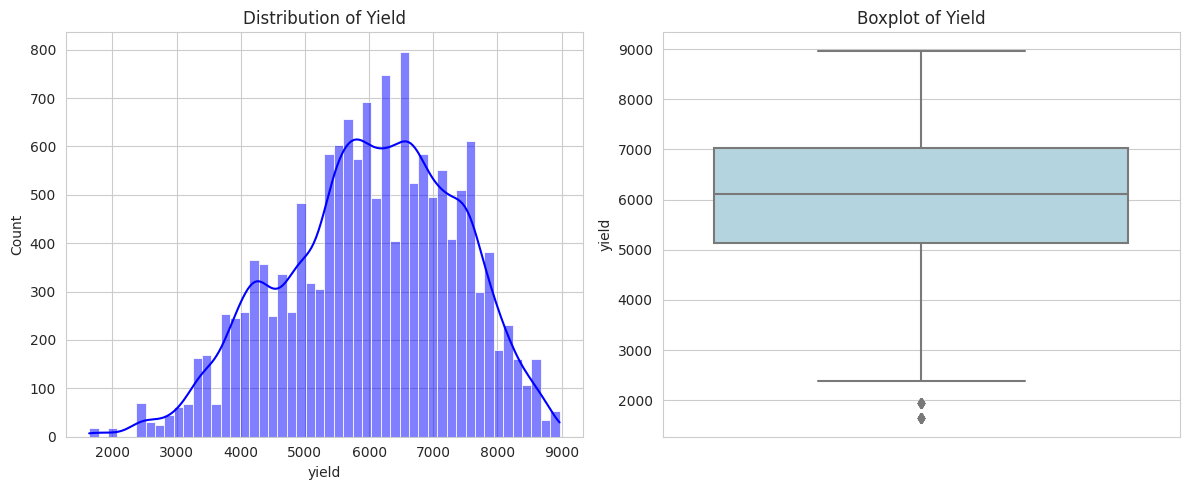

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(train['yield'], kde=True, bins=50, color='blue')
plt.title('Distribution of Yield')

plt.subplot(1,2,2)
sns.boxplot(y=train['yield'], color='lightblue')
plt.title('Boxplot of Yield')
plt.tight_layout()
plt.show()

# corr yield

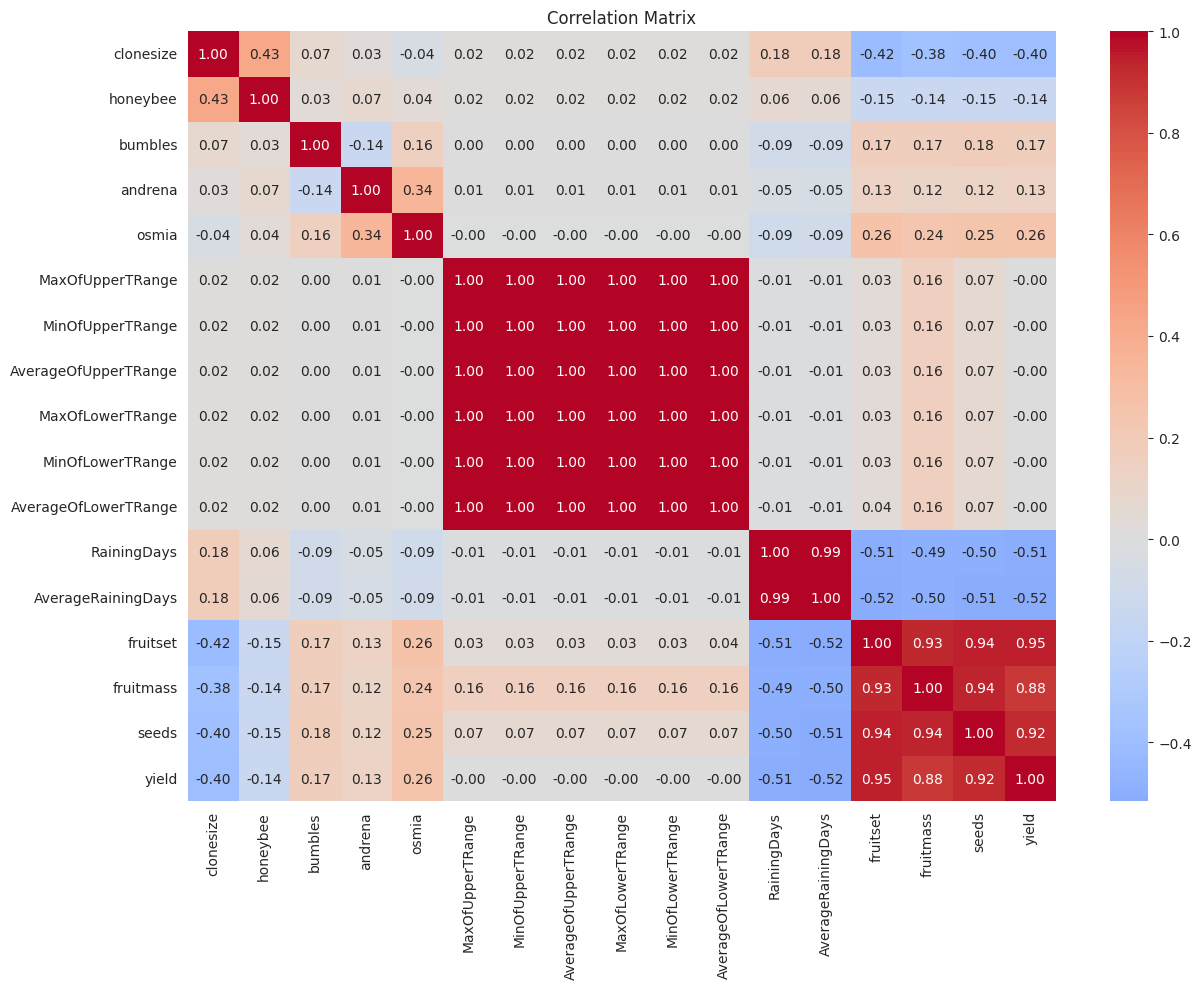

In [8]:
corr = train.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [9]:
print(corr['yield'].sort_values(key=abs, ascending=False))

yield                   1.000000
fruitset                0.950334
seeds                   0.918796
fruitmass               0.884552
AverageRainingDays     -0.515687
RainingDays            -0.505014
clonesize              -0.399833
osmia                   0.259302
bumbles                 0.166672
honeybee               -0.138283
andrena                 0.129136
MaxOfUpperTRange       -0.000767
MaxOfLowerTRange       -0.000756
MinOfLowerTRange       -0.000718
AverageOfUpperTRange   -0.000617
MinOfUpperTRange       -0.000546
AverageOfLowerTRange   -0.000298
Name: yield, dtype: float64


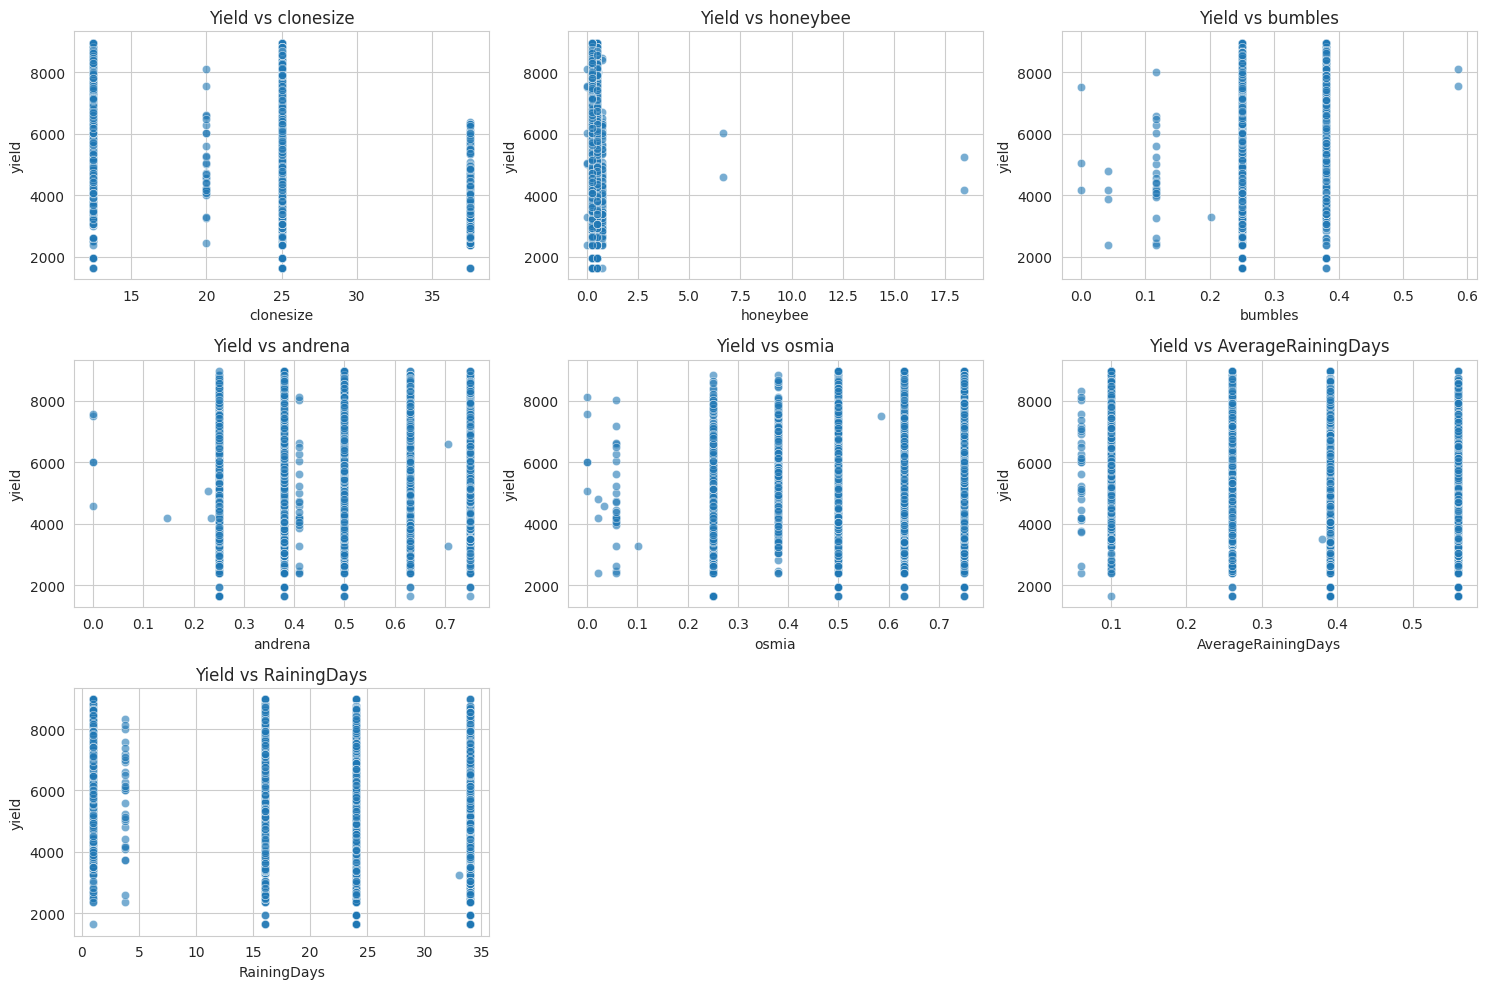

In [10]:
important_features = ['clonesize', 'honeybee', 'bumbles', 'andrena', 'osmia', 'AverageRainingDays', 'RainingDays']
plt.figure(figsize=(15,10))
for i, col in enumerate(important_features, 1):
    plt.subplot(3,3,i)
    sns.scatterplot(data=train, x=col, y='yield', alpha=0.6)
    plt.title(f'Yield vs {col}')
plt.tight_layout()
plt.show()

# Feature Engineering

In [11]:
def create_features(df):
    data = df.copy()
    
    
    data['bee_density'] = data['honeybee'] + data['bumbles'] + data['andrena'] + data['osmia']
    data['bee_per_clone'] = data['bee_density'] / data['clonesize']
    data['honeybee_importance'] = data['honeybee'] * data['clonesize']
    
    
    data['temp_range'] = data['MaxOfUpperTRange'] - data['MinOfLowerTRange']
    data['avg_temp'] = (data['AverageOfUpperTRange'] + data['AverageOfLowerTRange']) / 2
    data['rain_impact'] = data['RainingDays'] * data['AverageRainingDays']
    

    for col in ['clonesize', 'honeybee', 'osmia', 'AverageRainingDays', 'temp_range']:
        data[f'{col}_sq'] = data[col] ** 2
    

    data['fruit_per_seed'] = data['fruitmass'] / data['seeds']
    data['seed_per_fruit'] = data['seeds'] / data['fruitmass']
    

    cluster_features = ['clonesize', 'honeybee', 'osmia', 'AverageRainingDays', 'avg_temp']
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data[cluster_features])
    kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
    data['cluster'] = kmeans.fit_predict(scaled)
    
    return data

In [12]:
X_full = create_features(train)
test_full = create_features(test)

y = X_full['yield']
X = X_full.drop('yield', axis=1)

print(f"number of the new feature : {X.shape[1]} (from {train.shape[1]-2} firest)")

number of the new feature : 30 (from 15 firest)


In [13]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'tree_method': 'hist',
        'early_stopping_rounds': 100,
    }
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)   
    mae_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
        
        preds = model.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, preds))
    
    return np.mean(mae_scores)

In [14]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, timeout=None)
best_params = study.best_trial.params
print(best_params)
print(f"The best Cv in MAE: {study.best_value:.4f}")

[I 2025-12-20 08:39:08,454] A new study created in memory with name: no-name-6a431523-be9a-4b81-8227-dca37f1f6f62
[I 2025-12-20 08:39:17,055] Trial 0 finished with value: 257.9899637971094 and parameters: {'n_estimators': 1062, 'learning_rate': 0.0862735828664018, 'max_depth': 9, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 257.9899637971094.
[I 2025-12-20 08:40:12,181] Trial 1 finished with value: 252.9412388915 and parameters: {'n_estimators': 1562, 'learning_rate': 0.005318033256270142, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 1 with value: 252.9412388915.
[I 2025-12-20 08:40:36,220] Trial 2 finished with value: 251.77566819108333 an

{'n_estimators': 1794, 'learning_rate': 0.01140275390670109, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.7385259401264185, 'colsample_bytree': 0.9665950920565979, 'gamma': 2.6480200428258023, 'reg_alpha': 0.27869587711960553, 'reg_lambda': 1.1018693818418595}
The best Cv in MAE: 248.2445


# Ensembling and OFF

In [15]:
kf = KFold(n_splits=20, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_full))
mae_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Training Fold {fold+1}/10...")
    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBRegressor(**best_params,
                         random_state=42,
                         tree_method='hist')
    
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=False)
    
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(test_full) / 10 
    
    fold_mae = mean_absolute_error(y_val, val_pred)
    mae_scores.append(fold_mae)
    print(f"Fold {fold+1} MAE: {fold_mae:.4f}")



print(f"mean OOF MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Best fold: {min(mae_scores):.4f}")

Training Fold 1/10...
Fold 1 MAE: 245.2278
Training Fold 2/10...
Fold 2 MAE: 242.4466
Training Fold 3/10...
Fold 3 MAE: 261.7509
Training Fold 4/10...
Fold 4 MAE: 269.0912
Training Fold 5/10...
Fold 5 MAE: 243.6358
Training Fold 6/10...
Fold 6 MAE: 267.6630
Training Fold 7/10...
Fold 7 MAE: 245.1544
Training Fold 8/10...
Fold 8 MAE: 245.2042
Training Fold 9/10...
Fold 9 MAE: 246.1536
Training Fold 10/10...
Fold 10 MAE: 256.7892
Training Fold 11/10...
Fold 11 MAE: 240.2414
Training Fold 12/10...
Fold 12 MAE: 247.1119
Training Fold 13/10...
Fold 13 MAE: 257.5105
Training Fold 14/10...
Fold 14 MAE: 260.0283
Training Fold 15/10...
Fold 15 MAE: 250.4618
Training Fold 16/10...
Fold 16 MAE: 251.4486
Training Fold 17/10...
Fold 17 MAE: 242.0651
Training Fold 18/10...
Fold 18 MAE: 250.5366
Training Fold 19/10...
Fold 19 MAE: 247.9344
Training Fold 20/10...
Fold 20 MAE: 250.1744
mean OOF MAE: 251.0315 ± 8.2200
Best fold: 240.2414


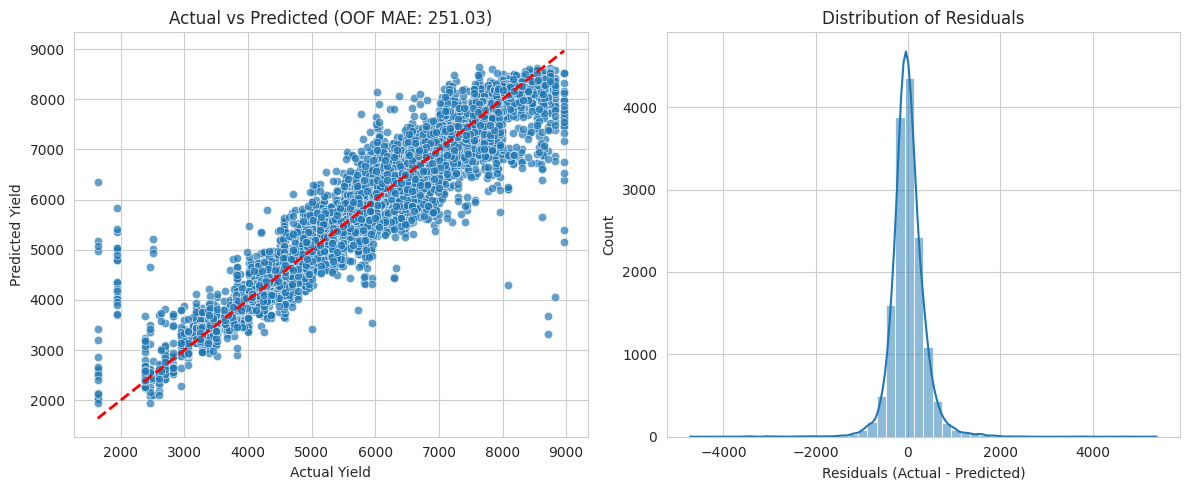

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y, y=oof_preds, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title(f'Actual vs Predicted (OOF MAE: {np.mean(mae_scores):.2f})')

plt.subplot(1,2,2)
residuals = y - oof_preds
sns.histplot(residuals, kde=True, bins=50)
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

In [17]:
submission = pd.DataFrame({
    'id': test_ids,
    'yield': test_preds
})

submission.to_csv('submission.csv', index=False)
display(submission.head(10))

,id,yield
0,15000,15049.558533
1,15001,11539.381287
2,15002,13465.943176
3,15003,9298.804840
4,15004,11790.047607
5,15005,12831.143982
6,15006,14747.571960
7,15007,13025.707825
8,15008,14864.912415
9,15009,11608.034180


In [18]:
submission.to_csv('submission.csv', index=False) 